# Transit extraction

Kind of a crazy hail mary idea here, considering there are about two days left in the competition. But, I have a plan to introduce more data diversity, better isolate the plane's atmospheric signal, and make the inputs to the model smaller.

This is a different strategy than the time point based sampling of the extracted frames I have been using. For it to work, I need to start with the planet frames (wavelengths, time points). So in theory, we could add it to the data preprocessing pipeline as an additional, maybe optional step.

Steps are, per-planet:

1. Identify transit and non-transit captures using the total signal
2. Split the planet image into transit and non-transit
3. Create n versions of each transit capture spectrum by subtracting each non-transit capture spectrum

On additional wrinkle here on the topic of spectroscopy in general - I expect anything interesting in the planet's atmosphere to absorb IR, so we are really looking for stuff that's missing from the star's spectrum during the transit. But I don't know if that is what is in the given ground truth spectra. It could be the planet's absorbance spectrum - i.e. strongly absorbed wavelengths show up as peaks, or it could be the transmitted spectrum, with the star's emission profile removed - i.g. strongly absorbed wavelengths show up as valleys.

If we had more time, we could make some test submission to try out both strategies - but at this point, we are out of time. Need to just show a neural net the data and let it sort out the relationships.

## Notebook set up

In [1]:
# Set notebook root to project root
from helper_functions import set_project_root

set_project_root()

# Standard library imports
from pathlib import Path
from random import shuffle

# Third party imports
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Local imports
from ariel_data_preprocessing.utils import load_masked_frames
import configuration as config

# Make sure the figures directory exists
figures_dir = f'{config.FIGURES_DIRECTORY}/signal_extraction'
Path(figures_dir).mkdir(parents=True, exist_ok=True)

Working directory: /mnt/arkk/kaggle/ariel-data-challenge


## 1. Load corrected/extracted data for a sample planet

In [2]:
# Load corrected/extracted data for a sample planet
with h5py.File(f'{config.PROCESSED_DATA_DIRECTORY}/train.h5', 'r') as hdf:
    signal, planet_id = load_masked_frames(hdf, planet='random', return_id=True)

## 2. Find transit start and end indices

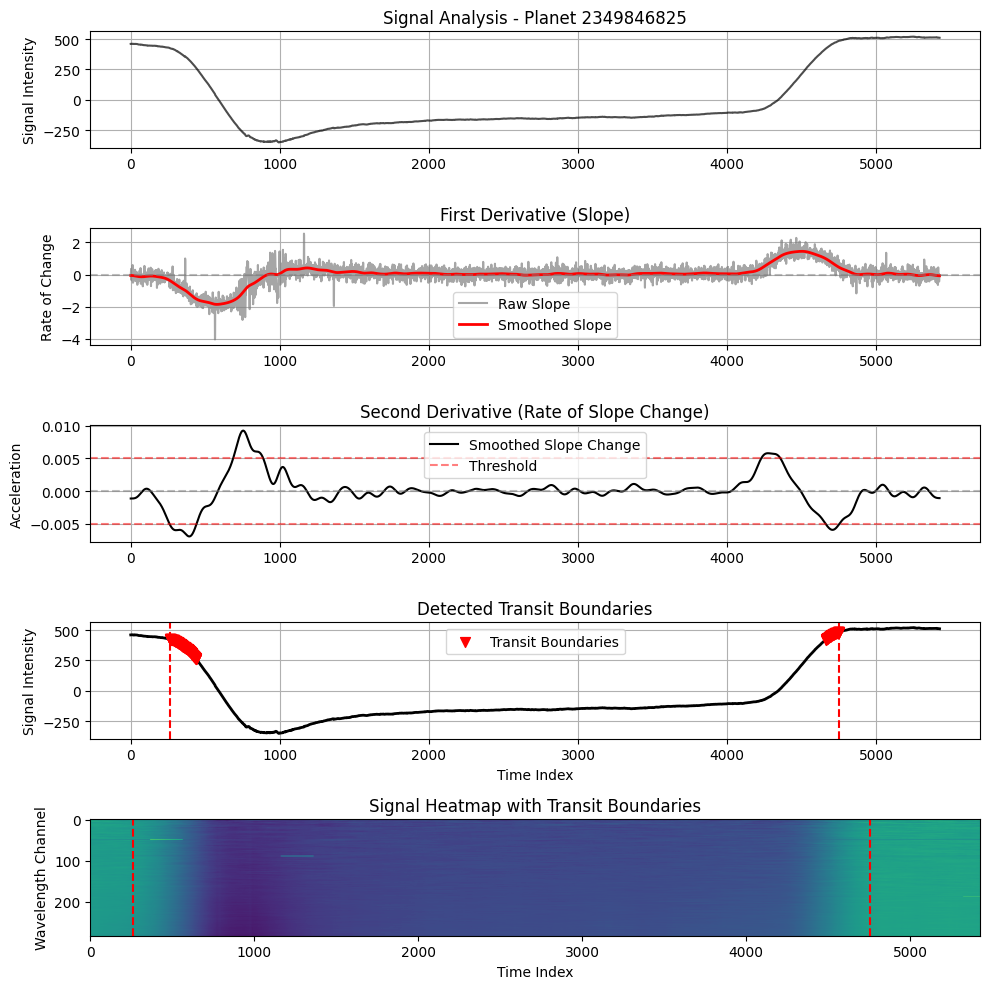

In [3]:
# Sum the signal across all wavelength channels to get a 1D time series
total_signal = np.sum(signal, axis=1)

# Calculate first derivative (slope)
slope = np.gradient(total_signal)

# Smooth the first derivative before calculating second derivative
smoothed_slope = gaussian_filter1d(slope, sigma=30)

# Calculate second derivative (rate of slope change) using smoothed slope
slope_change = np.gradient(smoothed_slope)

smoothed_slope_change = gaussian_filter1d(slope_change, sigma=30)

# Find regions where slope is changing most quickly
slope_change_threshold = np.std(smoothed_slope_change) * 2

# Find steep negative slope changes (rapid deceleration - transit start candidates)
transit_boundaries = np.where(smoothed_slope_change < -slope_change_threshold)[0]

# Plot comprehensive analysis
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

# Raw signal
axes[0].plot(total_signal, color='black', alpha=0.7)
axes[0].set_title(f'Signal Analysis - Planet {planet_id}')
axes[0].set_ylabel('Signal Intensity')
axes[0].grid(True)

# First derivative (slope) - both raw and smoothed
axes[1].plot(slope, label='Raw Slope', alpha=0.7, color='grey')
axes[1].plot(smoothed_slope, label='Smoothed Slope', linewidth=2, color='red')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('First Derivative (Slope)')
axes[1].set_ylabel('Rate of Change')
axes[1].legend()
axes[1].grid(True)

# Second derivative (slope change)
axes[2].plot(smoothed_slope_change, label='Smoothed Slope Change', color='black')
axes[2].axhline(y=slope_change_threshold, color='red', linestyle='--', alpha=0.5, label='Threshold')
axes[2].axhline(y=-slope_change_threshold, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Second Derivative (Rate of Slope Change)')
axes[2].set_ylabel('Acceleration')
axes[2].legend()
axes[2].grid(True)

# Transit boundaries overlaid on original signal
axes[3].plot(total_signal, color='black', linewidth=2)
axes[3].scatter(transit_boundaries, total_signal[transit_boundaries], 
               color='red', s=50, marker='v', label='Transit Boundaries', zorder=5)
axes[3].axvline(x=transit_boundaries[0], color='red', linestyle='--')
axes[3].axvline(x=transit_boundaries[-1], color='red', linestyle='--')
axes[3].set_title('Detected Transit Boundaries')
axes[3].set_xlabel('Time Index')
axes[3].set_ylabel('Signal Intensity')
axes[3].legend()
axes[3].grid(True)

# Transit boundaries overlaid on signal heatmap
im = axes[4].imshow(signal.T, aspect='auto', cmap='viridis')
axes[4].axvline(x=transit_boundaries[0], color='red', linestyle='--')
axes[4].axvline(x=transit_boundaries[-1], color='red', linestyle='--')
axes[4].set_title('Signal Heatmap with Transit Boundaries')
axes[4].set_xlabel('Time Index')
axes[4].set_ylabel('Wavelength Channel')
axes[4].grid(False)

fig.tight_layout()

fig.savefig(
    f'{figures_dir}/02.8.1-transit_boundary_detection.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)

Obviously, this strategy is far from perfect. Just take a look at a few different planets, you will see some that have 'messy' transits - i.e. one of the limbs is a long gradual slope. Or other examples were there is another strong dip in the overall intensity somewhere. I can also imagine cases where the entrance or exit is not contained in the time series. We need a good strategy to identify those.

OK, here's the idea. Most of the transit boundary indices we are coming up with are contiguous in two blocks: the left edge and the right edge. So let's difference this array - if the max difference is not more than a few frames, then we know something strange is going on.

## 3. Check for bad transits

In [4]:
# Calculate the first difference of transit boundaries
boundary_diffs = np.diff(transit_boundaries)

if max(boundary_diffs) > 20:
    print('Clean transit detected')

else:
    print("No clear separation between left and right edges - possible problematic transit")

Clean transit detected


If we don't find a clear left and right edge, let's just assume we are looking at a transit where the entrance or exit is not included in the data. In that case, we need to decide if the in-transit signal is before or after the boundry. We can do that by looking at the mean total signal per frame on either side of the boundary. It should be higher on the transit side and lower on the non-transit side.

## 4. Parse bad transits

Creating incomplete transit test cases...
Original clean transit: frames 261 to 4752
Transit midpoint: 2506

Testing: Missing transit start - frames 2506 to 5425
Expected: Entry missing - transit on left
Detected boundaries: [2128 2129 2130 2131 2132 2133 2134 2135 2136 2137 2138 2139 2140 2141
 2142 2143 2144 2145 2146 2147 2148 2149 2150 2151 2152 2153 2154 2155
 2156 2157 2158 2159 2160 2161 2162 2163 2164 2165 2166 2167 2168 2169
 2170 2171 2172 2173 2174 2175 2176 2177 2178 2179 2180 2181 2182 2183
 2184 2185 2186 2187 2188 2189 2190 2191 2192 2193 2194 2195 2196 2197
 2198 2199 2200 2201 2202 2203 2204 2205 2206 2207 2208 2209 2210 2211
 2212 2213 2214 2215 2216 2217 2218 2219 2220 2221 2222 2223 2224 2225
 2226 2227 2228 2229 2230 2231 2232 2233 2234 2235 2236 2237 2238 2239
 2240 2241 2242 2243 2244 2245 2246 2247 2248 2249 2250 2251 2252 2253
 2254 2255 2256 2257 2258 2259 2260 2261 2262 2263 2264 2265 2266 2267
 2268 2269 2270 2271 2272 2273 2274 2275 2276 2277 2278 2279 2280

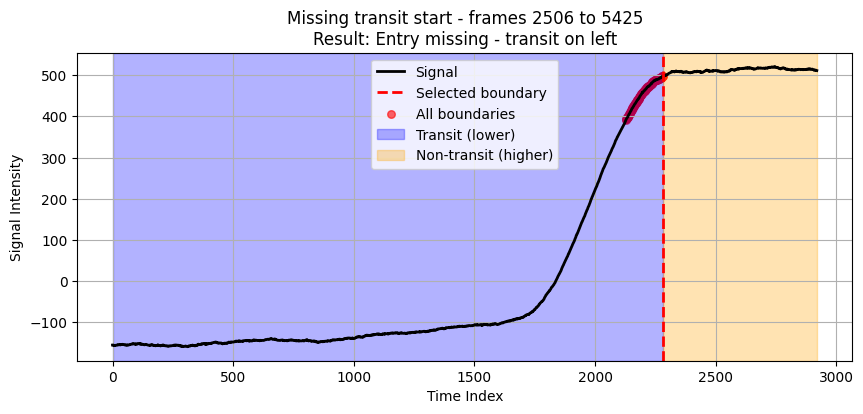


Testing: Missing transit end - frames 0 to 2505
Expected: Exit missing - transit on right
Detected boundaries: [291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 307 308
 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 326
 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344
 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360 361 362
 363 364 365 366 367 368 369 370 371 372 373 374 375 376 377 378 379 380
 381 382 383 384 385 386 387 388 389 390 391 392 393 394 395 396 397 398
 399 400 401 402 403 404 405 406 407 408 409 410 411 412 413 414 415 416
 417 418 419 420 421 422 423 424 425 426 427]
Max boundary diff: 1
✓ Correctly identified as incomplete transit
Selected boundary point: 291
Left region mean: 444.09
Right region mean: -156.10
Algorithm result: Exit missing - transit on right
Match expected: ✓


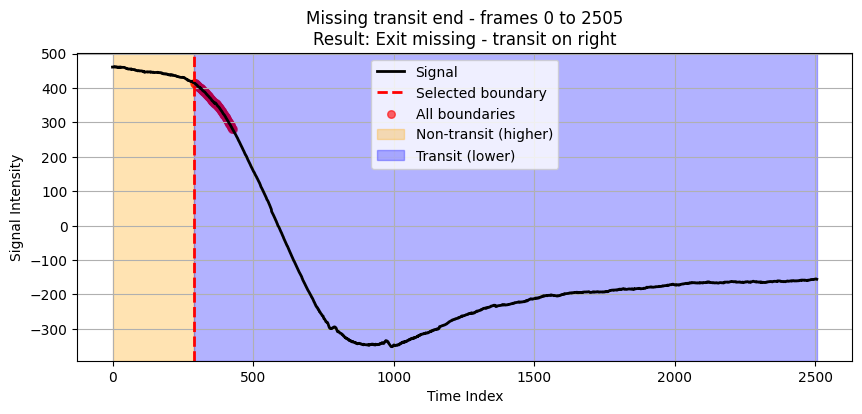

In [5]:
def create_incomplete_transit_test_cases(signal, transit_boundaries, boundary_diffs):
    """
    Create test cases for incomplete transit detection by truncating a clean transit.
    
    Parameters:
    - signal: Original signal array
    - transit_boundaries: Array of detected transit boundary indices
    - boundary_diffs: First differences of transit boundaries
    
    Returns:
    - test_cases: Dictionary containing different incomplete transit scenarios
    """
    
    # Only proceed if we have a clean transit
    if max(boundary_diffs) <= 20:
        print("Cannot create test cases - original transit is not clean")
        return None
    
    # Find the transit start and end from clean boundaries
    max_gap_idx = np.argmax(boundary_diffs)
    transit_start = transit_boundaries[0]
    transit_end = transit_boundaries[-1]
    transit_midpoint = (transit_start + transit_end) // 2
    
    print(f"Original clean transit: frames {transit_start} to {transit_end}")
    print(f"Transit midpoint: {transit_midpoint}")
    
    # Create test cases
    test_cases = {}
    
    # Test Case 1: Missing transit start (keep only second half)
    case1_start = transit_midpoint
    case1_signal = signal[case1_start:]
    case1_total_signal = np.sum(case1_signal, axis=1)
    test_cases['missing_start'] = {
        'signal': case1_signal,
        'total_signal': case1_total_signal,
        'description': f"Missing transit start - frames {case1_start} to {len(signal)-1}",
        'expected_classification': "Entry missing - transit on left"
    }
    
    # Test Case 2: Missing transit end (keep only first half)
    case2_end = transit_midpoint
    case2_signal = signal[:case2_end]
    case2_total_signal = np.sum(case2_signal, axis=1)
    test_cases['missing_end'] = {
        'signal': case2_signal,
        'total_signal': case2_total_signal,
        'description': f"Missing transit end - frames 0 to {case2_end-1}",
        'expected_classification': "Exit missing - transit on right"
    }
    
    return test_cases

def test_incomplete_transit_detection(test_case_data):
    """
    Test the incomplete transit detection algorithm on a test case.
    
    Parameters:
    - test_case_data: Dictionary containing test case signal and metadata
    """
    
    print(f"\nTesting: {test_case_data['description']}")
    print(f"Expected: {test_case_data['expected_classification']}")
    
    total_signal = test_case_data['total_signal']
    
    # Run the same boundary detection algorithm
    slope = np.gradient(total_signal)
    smoothed_slope = gaussian_filter1d(slope, sigma=30)
    slope_change = np.gradient(smoothed_slope)
    smoothed_slope_change = gaussian_filter1d(slope_change, sigma=30)
    slope_change_threshold = np.std(smoothed_slope_change) * 2
    transit_boundaries = np.where(smoothed_slope_change < -slope_change_threshold)[0]
    
    if len(transit_boundaries) == 0:
        print("No boundaries detected - test case may be too truncated")
        return
    
    boundary_diffs = np.diff(transit_boundaries)
    
    print(f"Detected boundaries: {transit_boundaries}")
    print(f"Max boundary diff: {max(boundary_diffs) if len(boundary_diffs) > 0 else 0}")
    
    # Test the incomplete transit handling code
    if len(boundary_diffs) == 0 or max(boundary_diffs) <= 20:
        print("✓ Correctly identified as incomplete transit")
        
        # First, determine which side has lower signal to identify transit region
        midpoint = len(total_signal) // 2
        left_half_mean = np.mean(total_signal[:midpoint])
        right_half_mean = np.mean(total_signal[midpoint:])
        
        # Select appropriate boundary based on where transit is located
        if left_half_mean < right_half_mean:
            # Transit is on left - use last boundary index
            boundary_point = transit_boundaries[-1]
            classification = "Entry missing - transit on left"
        else:
            # Transit is on right - use first boundary index  
            boundary_point = transit_boundaries[0]
            classification = "Exit missing - transit on right"
        
        # Calculate final region means using selected boundary
        left_region = total_signal[:boundary_point]
        right_region = total_signal[boundary_point:]
        left_mean = np.mean(left_region)
        right_mean = np.mean(right_region)
        
        print(f"Selected boundary point: {boundary_point}")
        print(f"Left region mean: {left_mean:.2f}")
        print(f"Right region mean: {right_mean:.2f}")
        print(f"Algorithm result: {classification}")
        print(f"Match expected: {'✓' if classification == test_case_data['expected_classification'] else '✗'}")
        
        # Visualize
        plt.figure(figsize=(10, 4))
        plt.plot(total_signal, 'k-', linewidth=2, label='Signal')
        plt.axvline(x=boundary_point, color='red', linestyle='--', linewidth=2, label='Selected boundary')
        
        # Scatter all detected boundaries for reference
        plt.scatter(transit_boundaries, total_signal[transit_boundaries], 
                   color='red', s=30, alpha=0.6, label='All boundaries')
        
        if left_mean < right_mean:
            plt.axvspan(0, boundary_point, alpha=0.3, color='blue', label='Transit (lower)')
            plt.axvspan(boundary_point, len(total_signal), alpha=0.3, color='orange', label='Non-transit (higher)')
        else:
            plt.axvspan(0, boundary_point, alpha=0.3, color='orange', label='Non-transit (higher)')
            plt.axvspan(boundary_point, len(total_signal), alpha=0.3, color='blue', label='Transit (lower)')
        
        plt.title(f'{test_case_data["description"]}\nResult: {classification}')
        plt.xlabel('Time Index')
        plt.ylabel('Signal Intensity')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    else:
        print("✗ Incorrectly identified as clean transit")
# Create and run test cases
print("Creating incomplete transit test cases...")
test_cases = create_incomplete_transit_test_cases(signal, transit_boundaries, boundary_diffs)

if test_cases is not None:
    # Test missing start case
    test_incomplete_transit_detection(test_cases['missing_start'])
    
    # Test missing end case  
    test_incomplete_transit_detection(test_cases['missing_end'])
else:
    print("Cannot create test cases - need a clean transit first")

## 5. Complete transit extraction function

Testing with complete original signal:


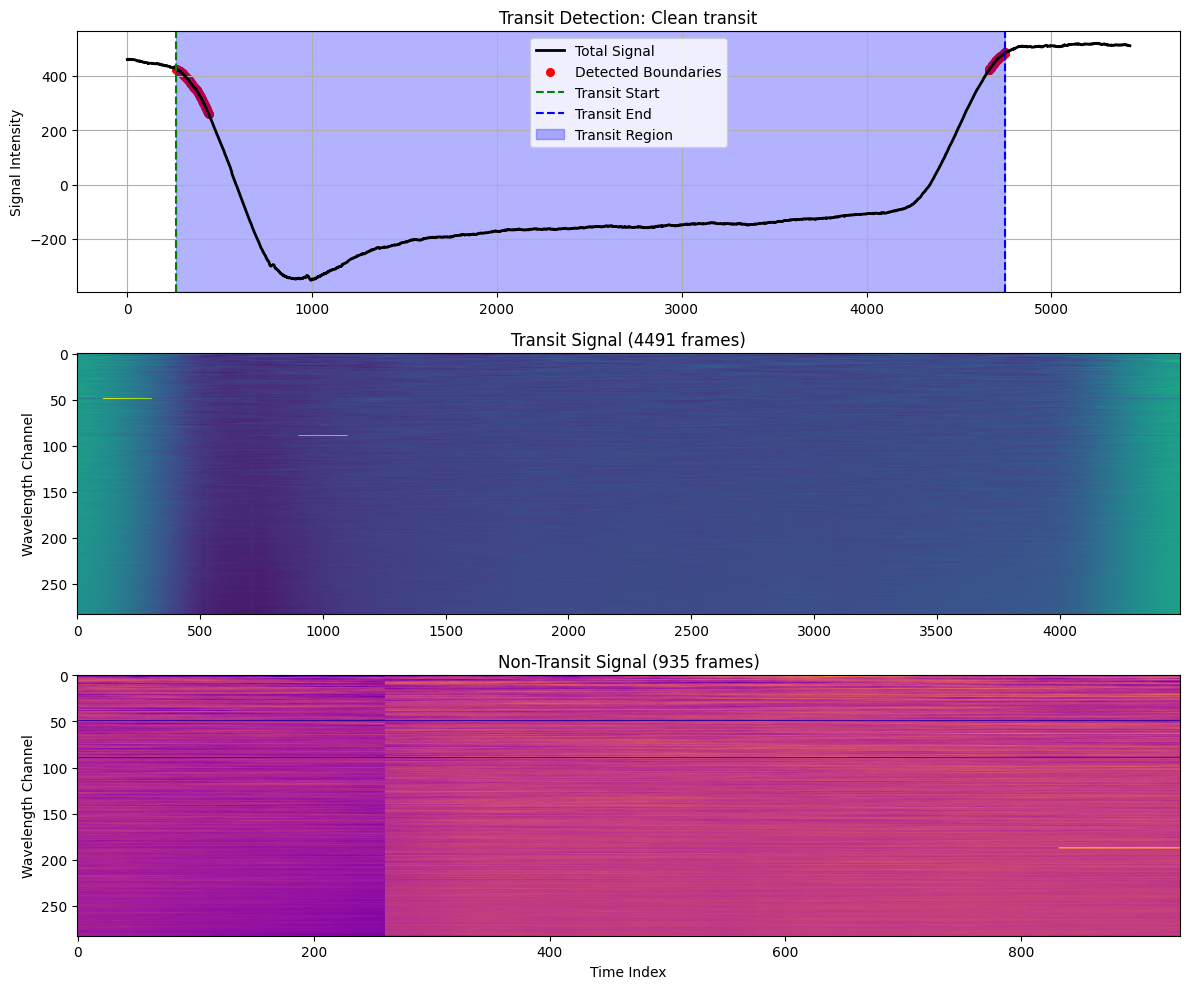

Transit Type: Clean transit
Transit frames: 4491
Non-transit frames: 935
Left region mean: 446.79
Right region mean: 511.28


Testing with missing start case:


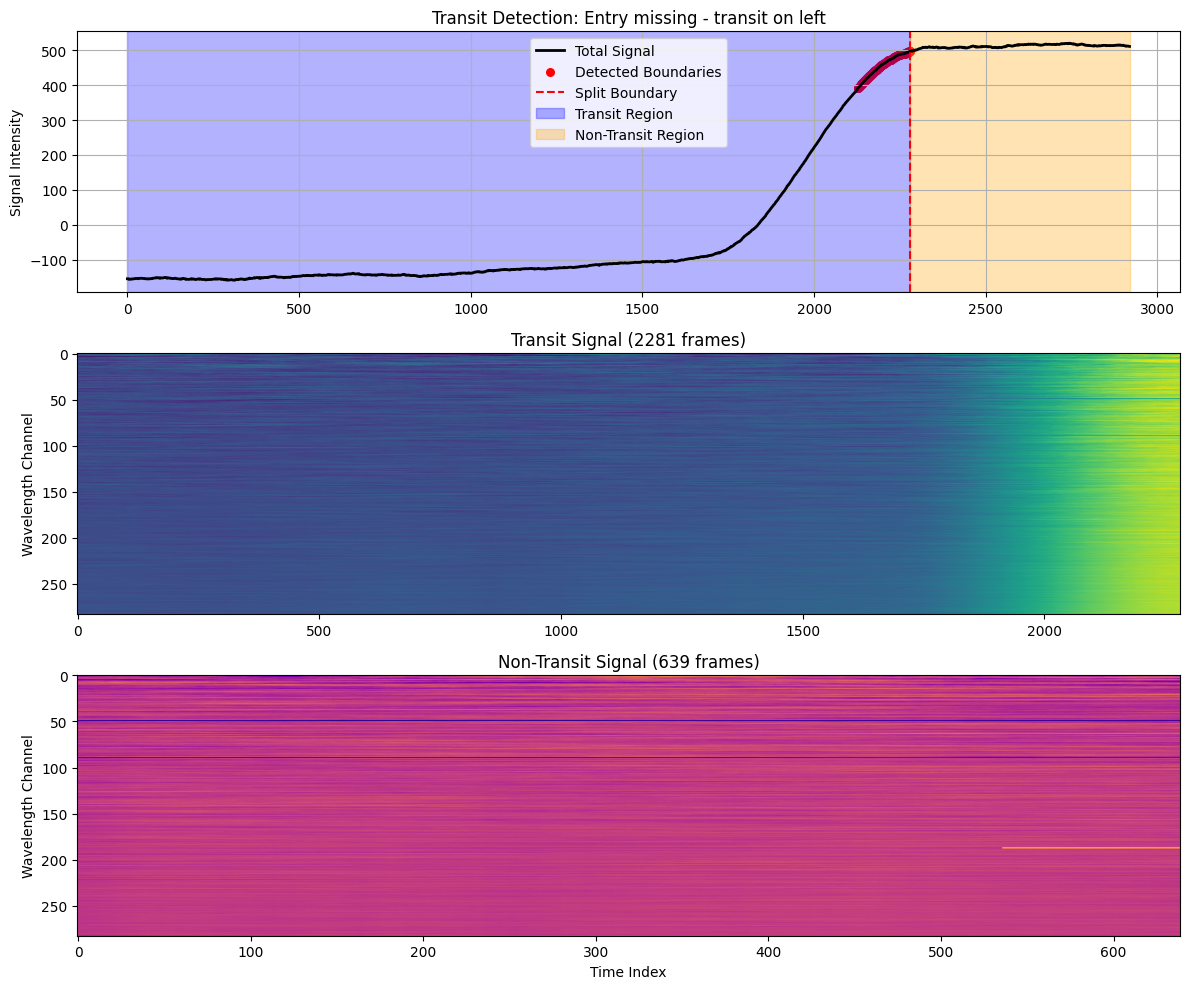

Transit Type: Entry missing - transit on left
Transit frames: 2281
Non-transit frames: 639
Left region mean: -48.60
Right region mean: 512.36


Testing with missing end case:


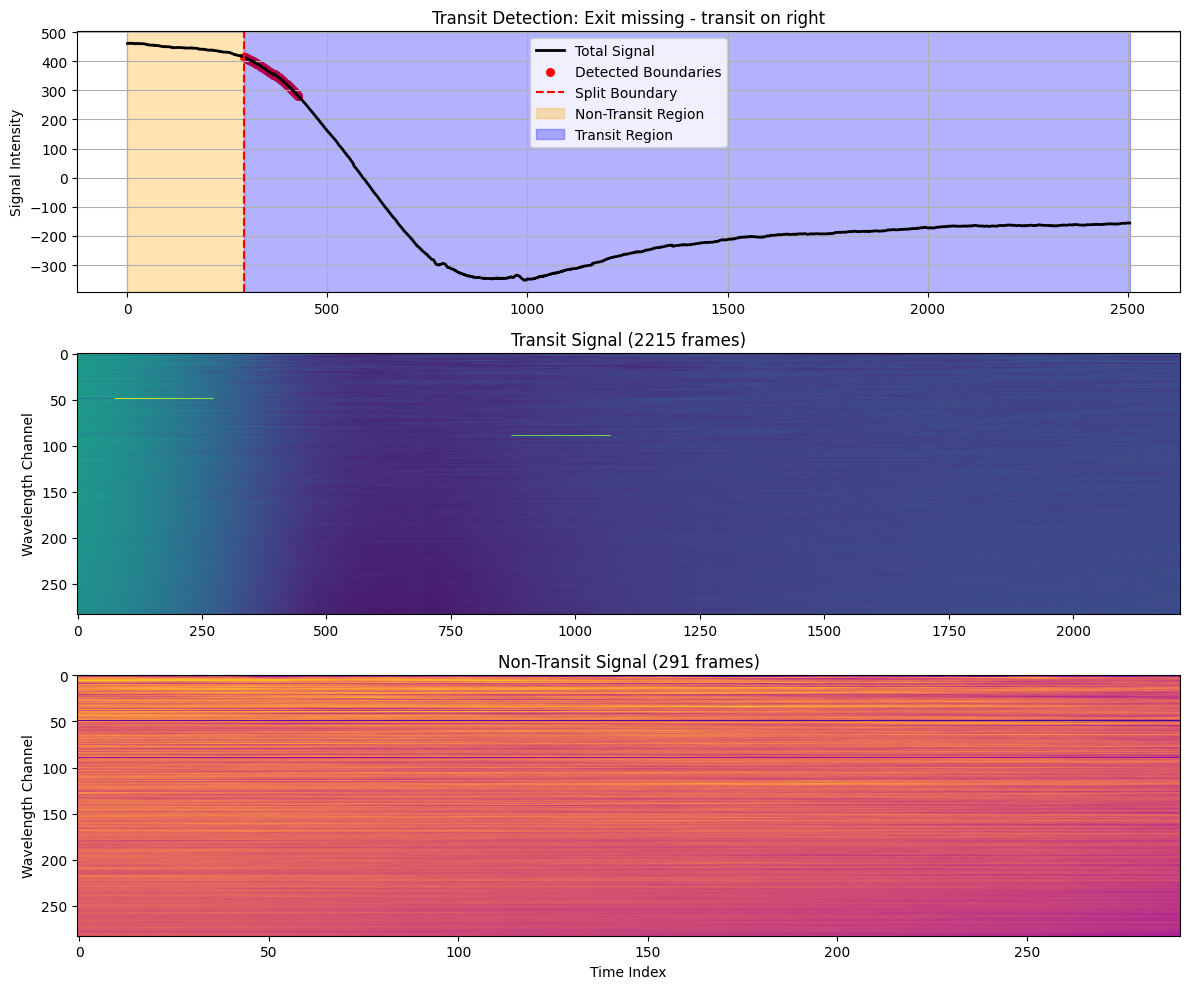

Transit Type: Exit missing - transit on right
Transit frames: 2215
Non-transit frames: 291
Left region mean: 444.09
Right region mean: -156.10


In [6]:
def extract_transit_regions(signal):
    """
    Extract transit and non-transit regions from a signal array.
    
    Parameters:
    - signal: 2D array of shape (time_points, wavelengths)
    
    Returns:
    - transit_signal: Array containing transit frames
    - non_transit_signal: Array containing non-transit frames
    - metadata: Dictionary with detection information
    """
    
    # Calculate total signal across wavelengths
    total_signal = np.sum(signal, axis=1)
    
    # Derivative-based boundary detection
    slope = np.gradient(total_signal)
    smoothed_slope = gaussian_filter1d(slope, sigma=30)
    slope_change = np.gradient(smoothed_slope)
    smoothed_slope_change = gaussian_filter1d(slope_change, sigma=30)
    slope_change_threshold = np.std(smoothed_slope_change) * 2
    transit_boundaries = np.where(smoothed_slope_change < -slope_change_threshold)[0]
    
    # Initialize metadata
    metadata = {
        'boundaries': transit_boundaries,
        'total_signal': total_signal,
        'boundary_point': None,
        'transit_type': None,
        'left_mean': None,
        'right_mean': None
    }
    
    if len(transit_boundaries) == 0:
        # No boundaries detected - return entire signal as non-transit
        metadata['transit_type'] = 'No transit detected'
        return np.array([]), signal, metadata
    
    # Calculate boundary differences
    boundary_diffs = np.diff(transit_boundaries) if len(transit_boundaries) > 1 else [0]
    max_boundary_diff = max(boundary_diffs) if len(boundary_diffs) > 0 else 0
    
    if max_boundary_diff > 20:
        # Clean transit - both start and end detected
        # Use first and last boundary indices for transit region
        transit_start = transit_boundaries[0]
        transit_end = transit_boundaries[-1]
        
        transit_signal = signal[transit_start:transit_end]
        non_transit_signal = np.vstack([
            signal[:transit_start],
            signal[transit_end:]
        ])
        
        metadata.update({
            'transit_type': 'Clean transit',
            'boundary_point': (transit_start, transit_end),
            'left_mean': np.mean(total_signal[:transit_start]),
            'right_mean': np.mean(total_signal[transit_end:])
        })
        
    else:
        # Incomplete transit - missing start or end
        # Determine which side has lower signal to identify transit region
        midpoint = len(total_signal) // 2
        left_half_mean = np.mean(total_signal[:midpoint])
        right_half_mean = np.mean(total_signal[midpoint:])
        
        # Select appropriate boundary based on where transit is located
        if left_half_mean < right_half_mean:
            # Transit is on left - use last boundary index
            boundary_point = transit_boundaries[-1]
            transit_signal = signal[:boundary_point]
            non_transit_signal = signal[boundary_point:]
            transit_type = "Entry missing - transit on left"
        else:
            # Transit is on right - use first boundary index  
            boundary_point = transit_boundaries[0]
            transit_signal = signal[boundary_point:]
            non_transit_signal = signal[:boundary_point]
            transit_type = "Exit missing - transit on right"
        
        # Calculate final region means
        left_mean = np.mean(total_signal[:boundary_point])
        right_mean = np.mean(total_signal[boundary_point:])
        
        metadata.update({
            'transit_type': transit_type,
            'boundary_point': boundary_point,
            'left_mean': left_mean,
            'right_mean': right_mean
        })
    
    return transit_signal, non_transit_signal, metadata


def visualize_transit_extraction(signal, transit_signal, non_transit_signal, metadata):
    """
    Visualize the results of transit extraction.
    """
    total_signal = metadata['total_signal']
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot 1: Total signal with boundaries
    axes[0].plot(total_signal, 'k-', linewidth=2, label='Total Signal')
    if len(metadata['boundaries']) > 0:
        axes[0].scatter(metadata['boundaries'], total_signal[metadata['boundaries']], 
                       color='red', s=30, label='Detected Boundaries')
    
    # Mark the actual separation point(s)
    if metadata['transit_type'] == 'Clean transit':
        start, end = metadata['boundary_point']
        axes[0].axvline(x=start, color='green', linestyle='--', label='Transit Start')
        axes[0].axvline(x=end, color='blue', linestyle='--', label='Transit End')
        axes[0].axvspan(start, end, alpha=0.3, color='blue', label='Transit Region')
    else:
        boundary = metadata['boundary_point']
        axes[0].axvline(x=boundary, color='red', linestyle='--', label='Split Boundary')
        
        if 'left' in metadata['transit_type']:
            axes[0].axvspan(0, boundary, alpha=0.3, color='blue', label='Transit Region')
            axes[0].axvspan(boundary, len(total_signal), alpha=0.3, color='orange', label='Non-Transit Region')
        else:
            axes[0].axvspan(0, boundary, alpha=0.3, color='orange', label='Non-Transit Region')
            axes[0].axvspan(boundary, len(total_signal), alpha=0.3, color='blue', label='Transit Region')
    
    axes[0].set_title(f'Transit Detection: {metadata["transit_type"]}')
    axes[0].set_ylabel('Signal Intensity')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Transit signal heatmap
    if transit_signal.size > 0:
        im1 = axes[1].imshow(transit_signal.T, aspect='auto', cmap='viridis')
        axes[1].set_title(f'Transit Signal ({transit_signal.shape[0]} frames)')
    else:
        axes[1].text(0.5, 0.5, 'No Transit Signal', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Transit Signal (Empty)')
    axes[1].set_ylabel('Wavelength Channel')
    
    # Plot 3: Non-transit signal heatmap
    if non_transit_signal.size > 0:
        im2 = axes[2].imshow(non_transit_signal.T, aspect='auto', cmap='plasma')
        axes[2].set_title(f'Non-Transit Signal ({non_transit_signal.shape[0]} frames)')
    else:
        axes[2].text(0.5, 0.5, 'No Non-Transit Signal', ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Non-Transit Signal (Empty)')
    axes[2].set_xlabel('Time Index')
    axes[2].set_ylabel('Wavelength Channel')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"Transit Type: {metadata['transit_type']}")
    print(f"Transit frames: {transit_signal.shape[0] if transit_signal.size > 0 else 0}")
    print(f"Non-transit frames: {non_transit_signal.shape[0] if non_transit_signal.size > 0 else 0}")
    if metadata['left_mean'] is not None:
        print(f"Left region mean: {metadata['left_mean']:.2f}")
        print(f"Right region mean: {metadata['right_mean']:.2f}")


# Test the function with the complete original signal
print("Testing with complete original signal:")
print("=" * 50)
transit_sig, non_transit_sig, meta = extract_transit_regions(signal)
visualize_transit_extraction(signal, transit_sig, non_transit_sig, meta)

# Test with the incomplete transit test cases
if 'test_cases' in locals() and test_cases is not None:
    print("\n\nTesting with missing start case:")
    print("=" * 50)
    transit_sig_test1, non_transit_sig_test1, meta_test1 = extract_transit_regions(test_cases['missing_start']['signal'])
    visualize_transit_extraction(test_cases['missing_start']['signal'], transit_sig_test1, non_transit_sig_test1, meta_test1)
    
    print("\n\nTesting with missing end case:")
    print("=" * 50)
    transit_sig_test2, non_transit_sig_test2, meta_test2 = extract_transit_regions(test_cases['missing_end']['signal'])
    visualize_transit_extraction(test_cases['missing_end']['signal'], transit_sig_test2, non_transit_sig_test2, meta_test2)
else:
    print("\nTest cases not available - creating them first...")
    test_cases = create_incomplete_transit_test_cases(signal, transit_boundaries, boundary_diffs)
    if test_cases is not None:
        print("\nTesting with missing start case:")
        print("=" * 50)
        transit_sig_test1, non_transit_sig_test1, meta_test1 = extract_transit_regions(test_cases['missing_start']['signal'])
        visualize_transit_extraction(test_cases['missing_start']['signal'], transit_sig_test1, non_transit_sig_test1, meta_test1)
        
        print("\n\nTesting with missing end case:")
        print("=" * 50)
        transit_sig_test2, non_transit_sig_test2, meta_test2 = extract_transit_regions(test_cases['missing_end']['signal'])
        visualize_transit_extraction(test_cases['missing_end']['signal'], transit_sig_test2, non_transit_sig_test2, meta_test2)

OK - I feel fine about it. We are out of time, so let's finalized by generating the final dataset for the planet by subtracting each transit spectrum from each non-transit spectrum. This will give us a set of 1D vectors for each planet, and each set will have (transit length x non-transit length) representations of the 'planet' spectrum. I just KNOW a DNN could learn that if we had time to validate and tune the data processing pipeline and do a proper neural net architecture/hyperparameter optimization. I'll do my best. Final submissions due at 7:59 PM EDT on Wednesday. That's under 48 hours to go.

## 6. Spectrum subtraction

Generating spectrum subtraction dataset...
Transit frames: 4491
Non-transit frames: 935
Wavelength channels: 283
Total combinations: 4199085
Generated dataset shape: (4199085, 283)


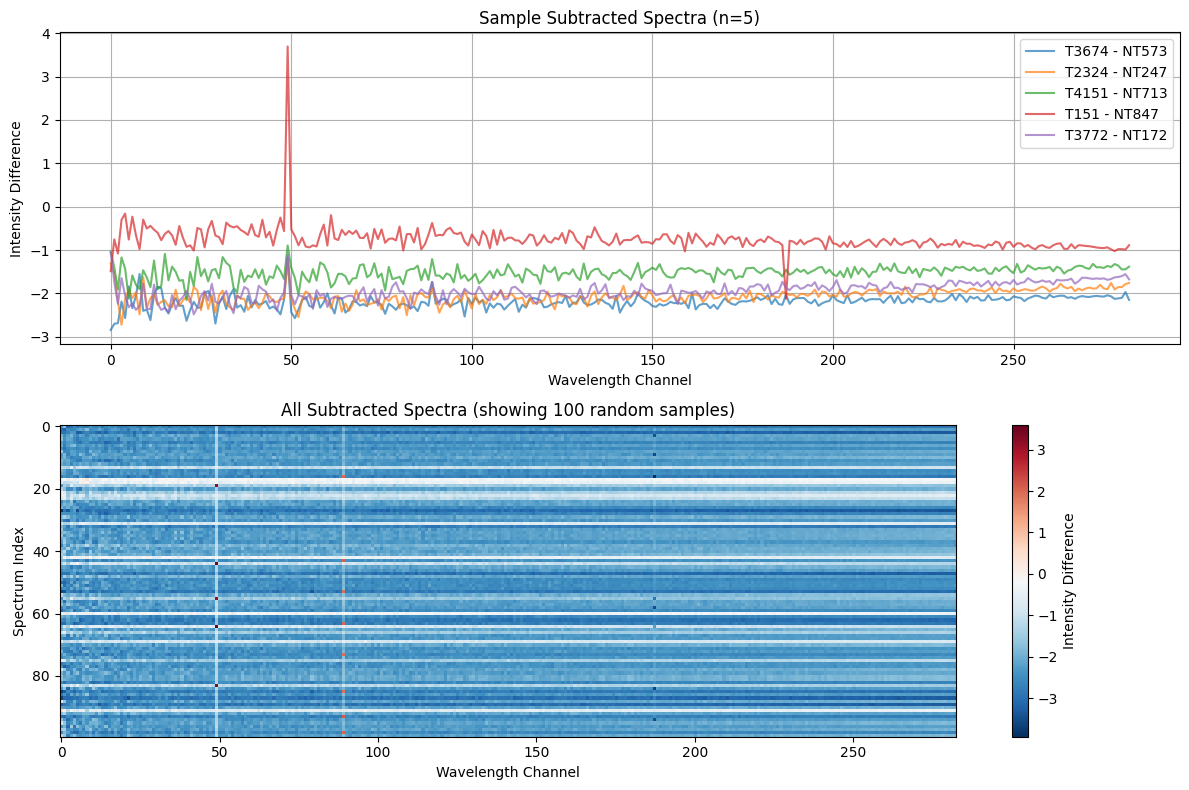


Dataset Statistics:
Shape: (4199085, 283)
Mean intensity difference: -2.1059
Std intensity difference: 0.6826
Min intensity difference: -4.5625
Max intensity difference: 3.8999


<Figure size 640x480 with 0 Axes>

In [7]:
def generate_spectrum_subtraction_dataset(transit_signal, non_transit_signal):
    """
    Generate final dataset by subtracting each non-transit spectrum from each transit spectrum.
    
    Parameters:
    - transit_signal: Array of shape (n_transit_frames, n_wavelengths)
    - non_transit_signal: Array of shape (n_non_transit_frames, n_wavelengths)
    
    Returns:
    - dataset: Array of shape (n_transit_frames * n_non_transit_frames, n_wavelengths)
               Each row represents one transit spectrum minus one non-transit spectrum
    - metadata: Dictionary containing information about the dataset generation
    """
    
    # Check if we have both transit and non-transit signals
    if transit_signal.size == 0:
        print("Warning: No transit signal available")
        return np.array([]), {'error': 'No transit signal'}
    
    if non_transit_signal.size == 0:
        print("Warning: No non-transit signal available")
        return np.array([]), {'error': 'No non-transit signal'}
    
    # Get dimensions
    n_transit_frames, n_wavelengths = transit_signal.shape
    n_non_transit_frames = non_transit_signal.shape[0]
    
    print(f"Transit frames: {n_transit_frames}")
    print(f"Non-transit frames: {n_non_transit_frames}")
    print(f"Wavelength channels: {n_wavelengths}")
    print(f"Total combinations: {n_transit_frames * n_non_transit_frames}")
    
    # Use broadcasting to perform all subtractions at once
    # Reshape transit_signal to (n_transit_frames, 1, n_wavelengths)
    # Reshape non_transit_signal to (1, n_non_transit_frames, n_wavelengths)
    # Broadcasting will create (n_transit_frames, n_non_transit_frames, n_wavelengths)
    transit_expanded = transit_signal[:, np.newaxis, :]  # Shape: (n_transit, 1, n_wavelengths)
    non_transit_expanded = non_transit_signal[np.newaxis, :, :]  # Shape: (1, n_non_transit, n_wavelengths)
    
    # Subtract non-transit from transit using broadcasting
    subtracted_spectra = transit_expanded - non_transit_expanded  # Shape: (n_transit, n_non_transit, n_wavelengths)
    
    # Reshape to final format: (n_transit * n_non_transit, n_wavelengths)
    dataset = subtracted_spectra.reshape(-1, n_wavelengths)
    
    # Create metadata
    metadata = {
        'n_transit_frames': n_transit_frames,
        'n_non_transit_frames': n_non_transit_frames,
        'n_wavelengths': n_wavelengths,
        'total_spectra': dataset.shape[0],
        'transit_indices': np.repeat(np.arange(n_transit_frames), n_non_transit_frames),
        'non_transit_indices': np.tile(np.arange(n_non_transit_frames), n_transit_frames)
    }
    
    print(f"Generated dataset shape: {dataset.shape}")
    
    return dataset, metadata


def visualize_spectrum_subtraction_dataset(dataset, metadata, n_samples=5):
    """
    Visualize a sample of the generated spectrum subtraction dataset.
    
    Parameters:
    - dataset: The generated dataset from generate_spectrum_subtraction_dataset
    - metadata: Metadata dictionary from generate_spectrum_subtraction_dataset  
    - n_samples: Number of random samples to plot
    """
    
    if dataset.size == 0:
        print("No dataset to visualize")
        return
    
    # Select random samples
    n_total = dataset.shape[0]
    sample_indices = np.random.choice(n_total, min(n_samples, n_total), replace=False)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Sample subtracted spectra
    for i, idx in enumerate(sample_indices):
        transit_idx = metadata['transit_indices'][idx]
        non_transit_idx = metadata['non_transit_indices'][idx]
        spectrum = dataset[idx]
        
        axes[0].plot(spectrum, alpha=0.7, 
                    label=f'T{transit_idx} - NT{non_transit_idx}')
    
    axes[0].set_title(f'Sample Subtracted Spectra (n={len(sample_indices)})')
    axes[0].set_xlabel('Wavelength Channel')
    axes[0].set_ylabel('Intensity Difference')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Heatmap of all subtracted spectra
    # Sample a subset if dataset is too large for visualization
    max_display = 100
    if dataset.shape[0] > max_display:
        display_indices = np.random.choice(dataset.shape[0], max_display, replace=False)
        display_data = dataset[display_indices]
        title_suffix = f' (showing {max_display} random samples)'
    else:
        display_data = dataset
        title_suffix = ''
    
    im = axes[1].imshow(display_data, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    axes[1].set_title(f'All Subtracted Spectra{title_suffix}')
    axes[1].set_xlabel('Wavelength Channel')
    axes[1].set_ylabel('Spectrum Index')
    plt.colorbar(im, ax=axes[1], label='Intensity Difference')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nDataset Statistics:")
    print(f"Shape: {dataset.shape}")
    print(f"Mean intensity difference: {np.mean(dataset):.4f}")
    print(f"Std intensity difference: {np.std(dataset):.4f}")
    print(f"Min intensity difference: {np.min(dataset):.4f}")
    print(f"Max intensity difference: {np.max(dataset):.4f}")


# Test the function with our extracted transit signals
print("Generating spectrum subtraction dataset...")
print("=" * 50)

final_dataset, dataset_metadata = generate_spectrum_subtraction_dataset(transit_sig, non_transit_sig)

if final_dataset.size > 0:
    visualize_spectrum_subtraction_dataset(final_dataset, dataset_metadata)
    
    # Save the figure
    plt.savefig(
        f'{figures_dir}/02.8.2-spectrum_subtraction_dataset.jpg',
        dpi=config.STD_FIG_DPI,
        bbox_inches='tight'
    )
else:
    print("Could not generate dataset - check transit/non-transit signals")